In [42]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import DBSCAN

import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df = pd.read_csv(
    "../data/processed/scouting_dashboard_data.csv"
)

df.head()

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Off,Crs,Int,TklW,OG,Cluster,PCA1,PCA2,Outlier,Archetype
0,1,Brenden Aaronson,us USA,"MF,FW",Leeds United,eng Premier League,24.0,2000.0,37,30,...,5,37,17,27,0,3,0.332583,-0.107235,1,Defensive Specialists
1,2,Jerome Abbey,eng ENG,MF,Wolves,eng Premier League,15.0,2009.0,1,0,...,1,0,1,0,0,0,-0.291409,-0.022817,1,Elite Attackers
2,3,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19.0,2006.0,3,2,...,0,3,2,4,0,0,-0.250289,-0.042822,1,Elite Attackers
3,4,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,19.0,2006.0,22,4,...,2,30,3,3,0,2,-0.103769,0.124970,1,Efficient Team Players
4,5,Himad Abdelli,dz ALG,MF,Marseille,fr Ligue 1,25.0,1999.0,8,1,...,0,1,2,1,0,0,-0.262591,-0.029175,1,Elite Attackers


In [44]:
FEATURES = [

    "Gls",
    "Ast",
    "Sh",
    "SoT",
    "TklW",
    "Int",
    "Crs"
]

In [45]:
scaler = MinMaxScaler()

scaled_features = scaler.fit_transform(
    df[FEATURES].fillna(0)
)

In [46]:
results = []

eps_values = [
    0.05,
    0.08,
    0.10,
    0.12,
    0.15,
    0.18,
    0.20
]

min_samples_values = [
    3,
    5,
    10,
    15,
    20
]

for eps in eps_values:

    for min_samples in min_samples_values:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = dbscan.fit_predict(
            scaled_features
        )

        n_clusters = len(set(labels))

        if -1 in labels:
            n_clusters -= 1

        n_outliers = list(labels).count(-1)

        if n_clusters > 1:

            try:

                score = silhouette_score(
                    scaled_features,
                    labels
                )

            except:

                score = -1

        else:

            score = -1

        results.append({

            "eps": eps,
            "min_samples": min_samples,
            "clusters": n_clusters,
            "outliers": n_outliers,
            "silhouette": round(score, 3)

        })

results_df = pd.DataFrame(results)

results_df

,eps,min_samples,clusters,outliers,silhouette
0,0.05,3,27,1338,-1
1,0.05,5,8,1463,-1
2,0.05,10,4,1588,-1
3,0.05,15,1,1638,-1
4,0.05,20,1,1684,-1
5,0.08,3,28,712,-1
6,0.08,5,6,864,-1
7,0.08,10,1,1046,-1
8,0.08,15,1,1100,-1
9,0.08,20,1,1174,-1


In [47]:
results_df.sort_values(
    by="silhouette",
    ascending=False
).head(20)

,eps,min_samples,clusters,outliers,silhouette
0,0.05,3,27,1338,-1
1,0.05,5,8,1463,-1
2,0.05,10,4,1588,-1
3,0.05,15,1,1638,-1
4,0.05,20,1,1684,-1
5,0.08,3,28,712,-1
6,0.08,5,6,864,-1
7,0.08,10,1,1046,-1
8,0.08,15,1,1100,-1
9,0.08,20,1,1174,-1


In [48]:
results_df.sort_values(
    by="clusters",
    ascending=False
).head(20)

,eps,min_samples,clusters,outliers,silhouette
5,0.08,3,28,712,-1
0,0.05,3,27,1338,-1
10,0.10,3,16,460,-1
15,0.12,3,12,264,-1
1,0.05,5,8,1463,-1
6,0.08,5,6,864,-1
11,0.10,5,5,556,-1
25,0.18,3,5,59,-1
2,0.05,10,4,1588,-1
30,0.20,3,3,43,-1


In [55]:
dbscan = DBSCAN(
    eps=0.18,
    min_samples=3
)

labels = dbscan.fit_predict(
    scaled_features
)

df["DBSCAN_Cluster"] = labels

df["DBSCAN_Cluster"].value_counts()

DBSCAN_Cluster
 0    2611
-1      59
 2       5
 1       4
 3       4
 4       4
Name: count, dtype: int64

In [50]:
df["DBSCAN_Cluster"].value_counts()

DBSCAN_Cluster
 0    2567
-1     120
Name: count, dtype: int64

In [56]:
cluster_profiles = df.groupby(
    "DBSCAN_Cluster"
)[FEATURES].mean()

cluster_profiles

,Gls,Ast,Sh,SoT,TklW,Int,Crs
DBSCAN_Cluster,,,,,,,
-1,8.593220,5.881356,65.423729,25.084746,29.000000,21.305085,106.016949
0,1.529682,1.066258,14.567216,4.938721,11.759479,10.071620,19.834546
1,1.500000,7.750000,25.000000,6.000000,35.250000,40.250000,226.750000
2,1.400000,1.400000,18.200000,5.200000,67.200000,37.800000,28.200000
3,5.500000,6.750000,47.000000,14.250000,10.750000,8.250000,156.750000
4,0.250000,0.750000,20.000000,4.000000,38.250000,73.750000,11.750000


In [52]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=42
)

pca_result = pca.fit_transform(
    scaled_features
)

df["PCA1"] = pca_result[:,0]
df["PCA2"] = pca_result[:,1]

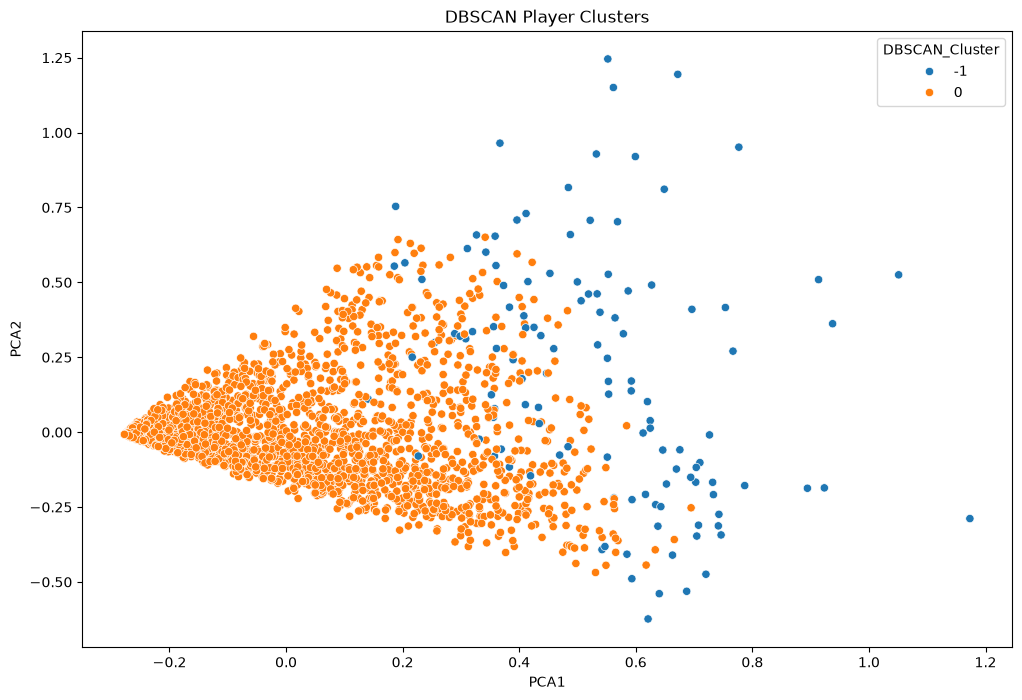

In [53]:
plt.figure(figsize=(12,8))

sns.scatterplot(

    data=df,

    x="PCA1",
    y="PCA2",

    hue="DBSCAN_Cluster",

    palette="tab10"
)

plt.title(
    "DBSCAN Player Clusters"
)

plt.show()

In [54]:
outliers = df[
    df["DBSCAN_Cluster"] == -1
]

outliers[[
    "Player",
    "Squad",
    "Pos"
]].head(50)

,Player,Squad,Pos
57,Ludovic Ajorque,Brest,FW
100,Nadiem Amiri,Mainz 05,MF
108,Elliot Anderson,Nottingham Forest,MF
128,Antony,Real Betis,"MF,FW"
131,Jon Aramburu,Real Sociedad,DF
215,Nicolò Barella,Inter,MF
223,Davide Bartesaghi,Milan,"MF,DF"
235,Christoph Baumgartner,RB Leipzig,MF
259,Jude Bellingham,Real Madrid,MF
278,Álex Berenguer,Athletic Club,MF
